# News Classifier | BBC Articles

Clasificador de noticias usando Transformers sobre el dataset BBC Articles.

**Luisa Fernanda Aristizabal, Ricardo Jose Garzon y Maria Fernanda Hurtado gomez**

### Instalacion de libreri­as e importacion 

In [19]:
%pip install -q --upgrade pip
%pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn transformers datasets accelerate nltk
%pip install -q --upgrade --force-reinstall torch --index-url https://download.pytorch.org/whl/cu128

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.


In [20]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from datasets import Dataset as HFDataset

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('Python:', os.sys.executable)
print('PyTorch:', torch.__version__)
print('CUDA build:', torch.version.cuda)

if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA no esta disponible en este kernel. '
        'Ejecuta la celda de instalacion, reinicia el kernel y vuelve a correr desde el inicio.'
    )

device = torch.device('cuda:0')
torch.cuda.set_device(device)
print(f'Usando device: {device} - {torch.cuda.get_device_name(0)}')

Python: c:\Users\USUARIO\AppData\Local\Python\pythoncore-3.14-64\python.exe
PyTorch: 2.11.0+cu128
CUDA build: 12.8
Usando device: cuda:0 - NVIDIA GeForce RTX 5060


In [21]:
# Descarga al cache global de kagglehub
path = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")
print('Cache:', path)

# Copia los CSVs a una carpeta data/ dentro del proyecto
PROJECT_DIR = os.getcwd()
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)

for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith('.csv'):
            src = os.path.join(root, f)
            dst = os.path.join(DATA_DIR, f)
            if not os.path.exists(dst):
                shutil.copy(src, dst)
            print('->', dst)

Cache: C:\Users\USUARIO\.cache\kagglehub\datasets\jacopoferretti\bbc-articles-dataset\versions\16
-> c:\Users\USUARIO\Desktop\transformers'bbc\DL-TRANSFORMERS\data\bbc_news_text_complexity_summarization.csv
-> c:\Users\USUARIO\Desktop\transformers'bbc\DL-TRANSFORMERS\data\bbc_text_cls.csv
-> c:\Users\USUARIO\Desktop\transformers'bbc\DL-TRANSFORMERS\data\bbc-news-data.csv


In [22]:
# Carga desde la carpeta data/ del proyecto
csv_files = sorted([os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
print('CSVs en data/:', csv_files)

# Usamos bbc_text_cls.csv que es el mÃƒÂ¡s limpio para clasificaciÃƒÂ³n (text + labels)
df = pd.read_csv(os.path.join(DATA_DIR, 'bbc_text_cls.csv'))
df.head()

CSVs en data/: ["c:\\Users\\USUARIO\\Desktop\\transformers'bbc\\DL-TRANSFORMERS\\data\\bbc-news-data.csv", "c:\\Users\\USUARIO\\Desktop\\transformers'bbc\\DL-TRANSFORMERS\\data\\bbc_news_text_complexity_summarization.csv", "c:\\Users\\USUARIO\\Desktop\\transformers'bbc\\DL-TRANSFORMERS\\data\\bbc_text_cls.csv"]


,text,labels
0,Ad sales boost Time Warner profit\r\n\r\nQuart...,business
1,Dollar gains on Greenspan speech\r\n\r\nThe do...,business
2,Yukos unit buyer faces loan claim\r\n\r\nThe o...,business
3,High fuel prices hit BA's profits\r\n\r\nBriti...,business
4,Pernod takeover talk lifts Domecq\r\n\r\nShare...,business


## Preprocesamiento

Como vamos a usar Transformers (BERT/DistilBERT), la limpieza es **mÃƒÂ­nima**: el tokenizer del modelo se encarga del resto. NO hacemos lowercasing, NO removemos stopwords, NO lematizamos.

###  EDA basico

In [23]:
print('Shape:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nNulos por columna:')
print(df.isnull().sum())
print('\nDuplicados:', df.duplicated().sum())
print('\nDistribuciÃƒÂ³n de clases:')
print(df['labels'].value_counts())

Shape: (2225, 2)

Columnas: ['text', 'labels']

Nulos por columna:
text      0
labels    0
dtype: int64

Duplicados: 98

DistribuciÃƒÂ³n de clases:
labels
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


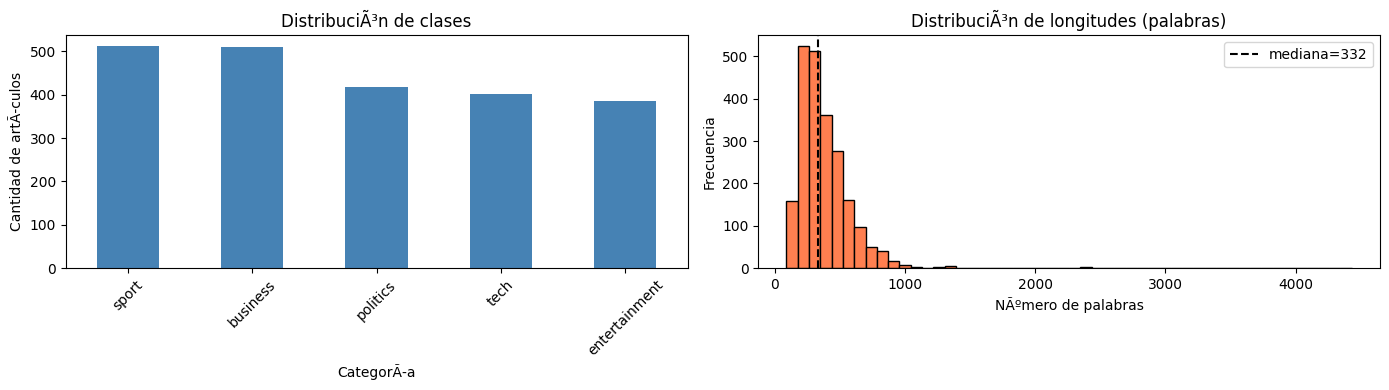

Longitud (palabras) Ã¢â‚¬â€ min: 89, max: 4432, media: 384, p95: 729


In [ ]:
# DistribuciÃƒÂ³n visual de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['labels'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('DistribuciÃƒÂ³n de clases')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Cantidad de articulos')
axes[0].tick_params(axis='x', rotation=45)

# DistribuciÃƒÂ³n de longitudes (en palabras) para definir max_length del tokenizer
df['n_words'] = df['text'].str.split().str.len()
axes[1].hist(df['n_words'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('DistribuciÃƒÂ³n de longitudes (palabras)')
axes[1].set_xlabel('NÃƒÂºmero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df['n_words'].median(), color='black', linestyle='--', label=f"mediana={df['n_words'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Longitud (palabras) Ã¢â‚¬â€ min: {df['n_words'].min()}, max: {df['n_words'].max()}, "
      f"media: {df['n_words'].mean():.0f}, p95: {df['n_words'].quantile(0.95):.0f}")

### Limpieza 

Solo lo necesario: drop nulos/duplicados, normalizar whitespace y remover URLs/HTML si los hay. **Mantenemos** mayÃƒÂºsculas, puntuaciÃƒÂ³n y stopwords.

In [ ]:
def clean_text(text: str) -> str:
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'<.*?>', ' ', text)              # HTML
    text = re.sub(r'\s+', ' ', text)                # whitespace mÃƒÂºltiple
    return text.strip()

# Aplicar limpieza
df = df.dropna(subset=['text', 'labels']).copy()
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
df['text'] = df['text'].astype(str).apply(clean_text)

# Eliminar textos vacÃƒÂ­os tras limpieza
df = df[df['text'].str.len() > 0].reset_index(drop=True)

print('Shape despues de limpieza:', df.shape)
df.head(2)

Shape despuÃƒÂ©s de limpieza: (2127, 3)


,text,labels,n_words
0,Ad sales boost Time Warner profit Quarterly pr...,business,421
1,Dollar gains on Greenspan speech The dollar ha...,business,384


### Encoding de labels

In [26]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['labels'])

# Mapeos id <-> nombre (los necesita el modelo)
id2label = {i: c for i, c in enumerate(le.classes_)}
label2id = {c: i for i, c in enumerate(le.classes_)}

print('Clases:', list(le.classes_))
print('id2label:', id2label)
print('Num labels:', len(le.classes_))

Clases: ['business', 'entertainment', 'politics', 'sport', 'tech']
id2label: {0: 'business', 1: 'entertainment', 2: 'politics', 3: 'sport', 4: 'tech'}
Num labels: 5


### Split estratificado: train / val / test (70/15/15)

In [27]:
SEED = 42

# Primero separamos test (15%)
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=SEED
)

# Luego separamos val del resto (15% del total Ã¢â€°Ë† 17.6% del 85% restante)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15/0.85, stratify=train_val_df['label'], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('\nDistribuciÃƒÂ³n por split:')
print(pd.DataFrame({
    'train': train_df['labels'].value_counts(normalize=True).round(3),
    'val':   val_df['labels'].value_counts(normalize=True).round(3),
    'test':  test_df['labels'].value_counts(normalize=True).round(3),
}))

Train: 1488 | Val: 319 | Test: 320

DistribuciÃƒÂ³n por split:
               train    val   test
labels                            
sport          0.237  0.238  0.238
business       0.237  0.235  0.238
politics       0.190  0.188  0.191
entertainment  0.173  0.176  0.172
tech           0.163  0.163  0.162


## Tokenizacion con el modelo

Cargamos el tokenizer del modelo elegido (RoBERTa) y tokenizamos los 3 splits. La limpieza ya estÃƒÂ¡ hecha en la secciÃƒÂ³n 4 Ã¢â‚¬â€ aquÃƒÂ­ solo convertimos texto a IDs.

### Configuracion: modelo y `max_length`


In [28]:
MODEL_NAME = 'roberta-base'
MAX_LENGTH = 256  # ajusta segÃƒÂºn el p95 que viste en 4.1

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer cargado: {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size}')
print(f'Max model length: {tokenizer.model_max_length}')
print(f'Special tokens: {tokenizer.all_special_tokens}')

Tokenizer cargado: roberta-base
Vocab size: 50265
Max model length: 512
Special tokens: ['<s>', '</s>', '<unk>', '<pad>', '<mask>']


### Verificacion: longitudes reales en tokens

Antes de fijar `MAX_LENGTH`, miramos la distribucion de longitudes en **tokens** (no palabras), que es lo que realmente le entra al modelo. Si el p95 en tokens supera mucho `MAX_LENGTH`,

In [29]:
sample_lengths = [len(tokenizer.encode(t, add_special_tokens=True, truncation=False))
                  for t in train_df['text'].sample(min(500, len(train_df)), random_state=SEED)]

import numpy as np
print(f'Longitudes en tokens (muestra de {len(sample_lengths)}):')
print(f'  min: {min(sample_lengths)}')
print(f'  media: {np.mean(sample_lengths):.0f}')
print(f'  mediana: {np.median(sample_lengths):.0f}')
print(f'  p95: {np.percentile(sample_lengths, 95):.0f}')
print(f'  max: {max(sample_lengths)}')
print(f'\n% de textos que se truncarÃƒÂ¡n con MAX_LENGTH={MAX_LENGTH}: '
      f'{100 * np.mean(np.array(sample_lengths) > MAX_LENGTH):.1f}%')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (587 > 512). Running this sequence through the model will result in indexing errors


Longitudes en tokens (muestra de 500):
  min: 170
  media: 498
  mediana: 418
  p95: 921
  max: 5220

% de textos que se truncarÃƒÂ¡n con MAX_LENGTH=256: 87.0%


### Dataset de PyTorch


In [30]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',     # rellena hasta max_length (todos los ejemplos misma forma)
            max_length=self.max_length,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),       # (max_length,)
            'attention_mask': enc['attention_mask'].squeeze(0),  # (max_length,)
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = NewsDataset(train_df['text'], train_df['label'], tokenizer, MAX_LENGTH)
val_dataset   = NewsDataset(val_df['text'],   val_df['label'],   tokenizer, MAX_LENGTH)
test_dataset  = NewsDataset(test_df['text'],  test_df['label'],  tokenizer, MAX_LENGTH)

print(f'train: {len(train_dataset)} | val: {len(val_dataset)} | test: {len(test_dataset)}')
print('\nEjemplo train_dataset[0]:')
sample = train_dataset[0]
for k, v in sample.items():
    print(f'  {k}: shape={tuple(v.shape)}, dtype={v.dtype}')

train: 1488 | val: 319 | test: 320

Ejemplo train_dataset[0]:
  input_ids: shape=(256,), dtype=torch.int64
  attention_mask: shape=(256,), dtype=torch.int64
  labels: shape=(), dtype=torch.int64


### DataLoaders



In [31]:
def create_dataloaders(batch_size, max_length=MAX_LENGTH):
    train_dataset = NewsDataset(train_df['text'], train_df['label'], tokenizer, max_length)
    val_dataset   = NewsDataset(val_df['text'],   val_df['label'],   tokenizer, max_length)
    test_dataset  = NewsDataset(test_df['text'],  test_df['label'],  tokenizer, max_length)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader

BATCH_SIZE = 16
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = create_dataloaders(
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
)

# Verificar un batch
batch = next(iter(train_loader))
print('train:', len(train_dataset), '| val:', len(val_dataset), '| test:', len(test_dataset))
print('Keys del batch:', list(batch.keys()))
print('input_ids shape:', batch['input_ids'].shape)        # (BATCH_SIZE, MAX_LENGTH)
print('attention_mask shape:', batch['attention_mask'].shape)
print('labels shape:', batch['labels'].shape)
print('labels:', batch['labels'])

train: 1488 | val: 319 | test: 320
Keys del batch: ['input_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([16, 256])
attention_mask shape: torch.Size([16, 256])
labels shape: torch.Size([16])
labels: tensor([0, 2, 0, 1, 2, 3, 4, 3, 3, 0, 0, 4, 4, 3, 3, 2])


## Arquitectura RoBERTa

Usamos `AutoModelForSequenceClassification` con `roberta-base`. Esta arquitectura carga RoBERTa preentrenado y agrega una cabeza de clasificacion para predecir las 5 categorias del dataset BBC.

In [32]:
def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(id2label),
        id2label=id2label,
        label2id=label2id,
    )
    return model.to(device)

model = build_model()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model.config.architectures)
print(f'Modelo cargado en: {next(model.parameters()).device}')
print(f'Parametros totales: {total_params:,}')
print(f'Parametros entrenables: {trainable_params:,}')

Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 197/197 [00:00<00:00, 5663.12it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


['RobertaForMaskedLM']
Modelo cargado en: cuda:0
Parametros totales: 124,649,477
Parametros entrenables: 124,649,477


### Configuracion de entrenamiento

Estos son los valores base. La busqueda prueba varias combinaciones y el entrenamiento final usa la mejor configuracion encontrada segun `val_f1`.

In [33]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

EPOCHS = 20
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_MIN_DELTA = 1e-4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0


def create_optimizer_and_scheduler(model, train_loader, epochs, learning_rate, weight_decay):
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    num_training_steps = epochs * len(train_loader)
    num_warmup_steps = int(0.1 * num_training_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
    )

    return optimizer, scheduler, num_training_steps, num_warmup_steps

optimizer, scheduler, num_training_steps, num_warmup_steps = create_optimizer_and_scheduler(
    model,
    train_loader,
    EPOCHS,
    LEARNING_RATE,
    WEIGHT_DECAY,
)

print(f'Max epochs: {EPOCHS}')
print(f'Early stopping patience: {EARLY_STOPPING_PATIENCE}')
print(f'Training steps: {num_training_steps}')
print(f'Warmup steps: {num_warmup_steps}')

Max epochs: 20
Early stopping patience: 2
Training steps: 1860
Warmup steps: 186


### Funciones de entrenamiento y evaluacion

In [34]:
def move_batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}


def train_one_epoch(model, dataloader, optimizer, scheduler, device, max_grad_norm=MAX_GRAD_NORM):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    progress = tqdm(dataloader, desc='Entrenando', leave=False)
    for batch in progress:
        batch = move_batch_to_device(batch, device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels'],
        )

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(batch['labels'].detach().cpu().numpy())
        progress.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate_model(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluando', leave=False):
            batch = move_batch_to_device(batch, device)
            outputs = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                labels=batch['labels'],
            )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(batch['labels'].detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0,
    )

    return {
        'loss': avg_loss,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'labels': all_labels,
        'preds': all_preds,
    }


def fit_model(
    model,
    train_loader,
    val_loader,
    epochs,
    learning_rate,
    weight_decay,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
    max_grad_norm=MAX_GRAD_NORM,
):
    optimizer, scheduler, _, _ = create_optimizer_and_scheduler(
        model,
        train_loader,
        epochs,
        learning_rate,
        weight_decay,
    )

    history = []
    best_val_f1 = -1.0
    best_model_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            device,
            max_grad_norm=max_grad_norm,
        )
        val_metrics = evaluate_model(model, val_loader, device)

        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_accuracy': train_acc,
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_f1': val_metrics['f1'],
        }
        history.append(row)

        print(
            f"Epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics['f1'] > best_val_f1 + min_delta:
            best_val_f1 = val_metrics['f1']
            best_epoch = epoch
            epochs_without_improvement = 0
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            epochs_without_improvement += 1
            print(f"Early stopping counter: {epochs_without_improvement}/{patience}")

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping en epoch {epoch}. "
                f"Mejor epoch: {best_epoch} con val_f1={best_val_f1:.4f}"
            )
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.to(device)

    return model, pd.DataFrame(history), best_val_f1, best_epoch

### Busqueda de hiperparametros y reentrenamiento final

Primero se prueban varias configuraciones por pocas epocas. Luego se reconstruyen los `DataLoaders`, se inicializa RoBERTa desde cero y se reentrena con la mejor configuracion hasta 20 epocas con early stopping.

In [35]:
HYPERPARAMETER_GRID = [
    {'learning_rate': 1e-5, 'batch_size': 16, 'weight_decay': 0.01, 'max_length': 256},
    {'learning_rate': 2e-5, 'batch_size': 16, 'weight_decay': 0.01, 'max_length': 256},
    {'learning_rate': 3e-5, 'batch_size': 16, 'weight_decay': 0.01, 'max_length': 256},
    {'learning_rate': 2e-5, 'batch_size': 8,  'weight_decay': 0.01, 'max_length': 256},
]

HP_SEARCH_EPOCHS = 4
HP_SEARCH_PATIENCE = 1

search_results = []

for run_id, params in enumerate(HYPERPARAMETER_GRID, start=1):
    print(f"\n=== Busqueda {run_id}/{len(HYPERPARAMETER_GRID)}: {params} ===")

    _, _, _, hp_train_loader, hp_val_loader, _ = create_dataloaders(
        batch_size=params['batch_size'],
        max_length=params['max_length'],
    )

    hp_model = build_model()
    hp_model, hp_history_df, hp_best_val_f1, hp_best_epoch = fit_model(
        model=hp_model,
        train_loader=hp_train_loader,
        val_loader=hp_val_loader,
        epochs=HP_SEARCH_EPOCHS,
        learning_rate=params['learning_rate'],
        weight_decay=params['weight_decay'],
        patience=HP_SEARCH_PATIENCE,
    )

    search_results.append({
        'run_id': run_id,
        **params,
        'best_val_f1': hp_best_val_f1,
        'best_epoch': hp_best_epoch,
    })

    del hp_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

search_results_df = pd.DataFrame(search_results).sort_values('best_val_f1', ascending=False)
best_hyperparams = search_results_df.iloc[0].to_dict()

print('\nMejores hiperparametros encontrados:')
print(best_hyperparams)
search_results_df


=== Busqueda 1/4: {'learning_rate': 1e-05, 'batch_size': 16, 'weight_decay': 0.01, 'max_length': 256} ===


Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 197/197 [00:00<00:00, 13803.28it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 | train_loss=1.1612 | train_acc=0.5585 | val_loss=0.1452 | val_acc=0.9812 | val_f1=0.9813


Epoch 2/4 | train_loss=0.1038 | train_acc=0.9832 | val_loss=0.0467 | val_acc=0.9906 | val_f1=0.9906


Epoch 3/4 | train_loss=0.0355 | train_acc=0.9940 | val_loss=0.0382 | val_acc=0.9937 | val_f1=0.9937


...

Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 197/197 [00:00<00:00, 13591.66it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 | train_loss=0.6714 | train_acc=0.7513 | val_loss=0.0737 | val_acc=0.9812 | val_f1=0.9812


Epoch 2/4 | train_loss=0.0623 | train_acc=0.9866 | val_loss=0.0511 | val_acc=0.9875 | val_f1=0.9875


Epoch 3/4 | train_loss=0.0184 | train_acc=0.9953 | val_loss=0.0582 | val_acc=0.9875 | val_f1=0.9874
Early stopping counter: 1/1
Early stopping en epoch 3. Mejor epoch: 2 con val_f1=0.9875

Mejores hiperparametros encontrados:
{'run_id': 1.0, 'learning_rate': 1e-05, 'batch_size': 16.0, 'weight_decay': 0.01, 'max_length': 256.0, 'best_val_f1': 0.9937321637118797, 'best_epoch': 3.0}


,run_id,learning_rate,batch_size,weight_decay,max_length,best_val_f1,best_epoch
0,1,0.00001,16,0.01,256,0.993732,3
1,2,0.00002,16,0.01,256,0.990615,2
3,4,0.00002,8,0.01,256,0.987493,2
2,3,0.00003,16,0.01,256,0.984390,2


### Reentrenamiento final con los mejores hiperparametros

In [36]:
LEARNING_RATE = float(best_hyperparams['learning_rate'])
BATCH_SIZE = int(best_hyperparams['batch_size'])
WEIGHT_DECAY = float(best_hyperparams['weight_decay'])
MAX_LENGTH = int(best_hyperparams['max_length'])

train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = create_dataloaders(
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
)

model = build_model()
model, history_df, best_val_f1, best_epoch = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
)

print(f'Entrenamiento final terminado. Mejor epoch: {best_epoch} | val_f1={best_val_f1:.4f}')
history_df

Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 197/197 [00:00<00:00, 12617.05it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/20 | train_loss=1.5926 | train_acc=0.2641 | val_loss=1.5189 | val_acc=0.3041 | val_f1=0.1997


Epoch 2/20 | train_loss=0.5645 | train_acc=0.8804 | val_loss=0.0913 | val_acc=0.9749 | val_f1=0.9750


Epoch 3/20 | train_loss=0.0693 | train_acc=0.9819 | val_loss=0.0400 | val_acc=0.9937 | val_f1=0.9937


Epoch 4/20 | train_loss=0.0125 | train_acc=0.9966 | val_loss=0.0452 | val_acc=0.9937 | val_f1=0.9937
Early stopping counter: 1/2


Epoch 5/20 | train_loss=0.0152 | train_acc=0.9973 | val_loss=0.0470 | val_acc=0.9906 | val_f1=0.9906
Early stopping counter: 2/2
Early stopping en epoch 5. Mejor epoch: 3 con val_f1=0.9937
Entrenamiento final terminado. Mejor epoch: 3 | val_f1=0.9937


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_f1
0,1,1.592637,0.264113,1.518907,0.304075,0.199687
1,2,0.564499,0.880376,0.091302,0.974922,0.975037
2,3,0.069327,0.981855,0.039956,0.993730,0.993732
3,4,0.012478,0.996640,0.045203,0.993730,0.993732
4,5,0.015184,0.997312,0.047029,0.990596,0.990600


### Evaluacion final: train / val / test / global

Train accuracy: 0.9987
Validation accuracy: 0.9937
Test accuracy: 0.9781
Accuracy global train+val+test: 0.9948

Metricas resumen:


,split,accuracy,precision,recall,f1,loss
0,train,0.998656,0.998656,0.998656,0.998656,0.013912
1,val,0.993730,0.993790,0.993730,0.993732,0.039956
2,test,0.978125,0.978259,0.978125,0.978117,0.088605
3,global_train_val_test,0.994828,NaN,NaN,NaN,NaN



Reporte por clase en test:
               precision    recall  f1-score   support

     business       0.96      0.97      0.97        76
entertainment       0.98      0.98      0.98        55
     politics       0.98      0.95      0.97        61
        sport       1.00      1.00      1.00        76
         tech       0.96      0.98      0.97        52

     accuracy                           0.98       320
    macro avg       0.98      0.98      0.98       320
 weighted avg       0.98      0.98      0.98       320



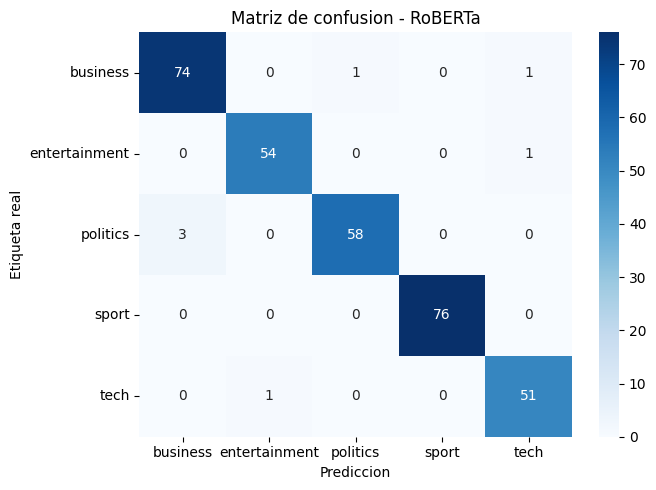

In [40]:
train_metrics = evaluate_model(model, train_loader, device)
val_metrics = evaluate_model(model, val_loader, device)
test_metrics = evaluate_model(model, test_loader, device)

all_labels = train_metrics['labels'] + val_metrics['labels'] + test_metrics['labels']
all_preds = train_metrics['preds'] + val_metrics['preds'] + test_metrics['preds']
overall_accuracy = accuracy_score(all_labels, all_preds)

def summarize_split(split_name, metrics):
    return {
        'split': split_name,
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'loss': metrics['loss'],
    }

accuracy_summary_df = pd.DataFrame([
    summarize_split('train', train_metrics),
    summarize_split('val', val_metrics),
    summarize_split('test', test_metrics),
    {
        'split': 'global_train_val_test',
        'accuracy': overall_accuracy,
        'precision': np.nan,
        'recall': np.nan,
        'f1': np.nan,
        'loss': np.nan,
    },
])

print(f"Train accuracy: {train_metrics['accuracy']:.4f}")
print(f"Validation accuracy: {val_metrics['accuracy']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.4f}")
print(f"Accuracy global train+val+test: {overall_accuracy:.4f}")

print('\nMetricas resumen:')
display(accuracy_summary_df)

print('\nReporte por clase en test:')
print(classification_report(
    test_metrics['labels'],
    test_metrics['preds'],
    target_names=[id2label[i] for i in range(len(id2label))],
    zero_division=0,
))

cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[id2label[i] for i in range(len(id2label))],
    yticklabels=[id2label[i] for i in range(len(id2label))],
)
plt.xlabel('Prediccion')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusion - RoBERTa')
plt.tight_layout()
plt.show()

### Predicciones reales

**Estos ejemplos seran utiles para el articulo**

In [41]:
def predict_texts(texts, model, tokenizer, max_length=MAX_LENGTH):
    model.eval()
    encoded = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='pt',
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)
        probabilities = torch.softmax(outputs.logits, dim=1)
        predicted_ids = torch.argmax(probabilities, dim=1).cpu().numpy()

    rows = []
    for text, pred_id, probs in zip(texts, predicted_ids, probabilities.cpu().numpy()):
        rows.append({
            'text': text,
            'predicted_label': id2label[int(pred_id)],
            'confidence': float(probs[int(pred_id)]),
        })

    return pd.DataFrame(rows)

sample_predictions_df = predict_texts(
    test_df['text'].head(10).tolist(),
    model,
    tokenizer,
    max_length=MAX_LENGTH,
)
sample_predictions_df.insert(
    1,
    'true_label',
    test_df['label'].head(10).map(id2label).to_list(),
)

sample_predictions_df

,text,true_label,predicted_label,confidence
0,Ferguson hails Man Utd's resolve Manchester Un...,sport,sport,0.995830
1,English clubs make Euro history All four of En...,sport,sport,0.995486
2,Hanks greeted at wintry premiere Hollywood sta...,entertainment,entertainment,0.995175
3,Britons growing 'digitally obese' Gadget lover...,tech,tech,0.992167
4,SA unveils 'more for all' budget The South Afr...,business,business,0.993832
5,Falconer rebuts 'charade' claims Concessions o...,politics,politics,0.995234
6,Comic Morris returns with sitcom Comedian Chri...,entertainment,entertainment,0.995146
7,Disputed Nirvana box set on sale A box set fea...,entertainment,entertainment,0.995243
8,Eminem secret gig venue revealed Rapper Eminem...,entertainment,entertainment,0.994998
9,High fuel costs hit US airlines Two of the lar...,business,business,0.994911
